# Privacy-Preserving Network Security\n## Classifying Encrypted Malicious Traffic with Ensemble ML\n### CICIDS2017 · SMOTE+Tomek · XGBoost · PR-AUC\n> **Authors**: Moeez Jamal (22i0513) · Ammad Nasir (22i0477)  \n> **Course**: Computer Networks — Semester Project Phase 2\n\n---\nThis notebook implements the full end-to-end pipeline:\n1. **Load** CICIDS2017 CSV files\n2. **EDA** — class distribution, feature correlation, missing-value audit\n3. **Preprocess** — clean, scale, encode\n4. **Resample** — SMOTETomek (hybrid over+under sampling)\n5. **Train** — XGBoost (primary), Random Forest, LightGBM, Voting Ensemble\n6. **Evaluate** — PR-AUC (primary), ROC-AUC, F1, Confusion Matrix\n7. **Compare** — side-by-side model benchmark

## 0 · Setup & Imports"

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath("src"))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
import joblib

from data_loader   import load_cicids2017, dataset_summary
from preprocessor  import run_preprocessing, split_features_labels, scale_features
from resampling    import resample
from models        import get_model, compute_sample_weights
from evaluation    import (evaluate, plot_confusion_matrix, plot_pr_curve,
                           plot_roc_curve, plot_feature_importance,
                           plot_class_distribution, plot_model_comparison,
                           PLOTS_DIR)

os.makedirs("outputs/models", exist_ok=True)
os.makedirs("outputs/plots",  exist_ok=True)
print("All imports OK.")
print(f"Plots will be saved to: {PLOTS_DIR.resolve()}")

All imports OK.
Plots will be saved to: C:\Users\USER\OneDrive\Desktop\cnet proj\outputs\plots


## 1 · Configuration\nSet `DATA_DIR` to the folder containing the CICIDS2017 CSV files.\nDownload from https://www.unb.ca/cic/datasets/ids-2017.html (MachineLearningCSV.zip).

In [2]:
# ── USER CONFIGURATION ──────────────────────────────────────────────────────
DATA_DIR       = "data/"         # folder with real CICIDS2017 CSV files
DEMO_MODE      = False           # False = use real CICIDS2017 CSVs
DEMO_SCALE     = 0.5             # only used when DEMO_MODE=True
SAMPLE_FRAC    = 0.15            # 0.15 = 15% rows (~315k samples, ~10 min total)
BINARY         = True            # True = BENIGN vs ATTACK | False = all 27 classes
RESAMPLE_STRAT = "smote_tomek"   # smote_tomek | smote | tomek | none
PRIMARY_MODEL  = "xgboost"       # xgboost | random_forest | lightgbm | ensemble
TEST_SIZE      = 0.20
RANDOM_STATE   = 42
# ─────────────────────────────────────────────────────────────────────────────
print("Configuration loaded.")
print(f"  Mode       : {'DEMO (synthetic data)' if DEMO_MODE else 'REAL (CICIDS2017 CSVs)'}")
print(f"  Sample     : {int(SAMPLE_FRAC*100)}% of real data" if not DEMO_MODE else f"  Demo scale : {DEMO_SCALE}")
print(f"  Binary     : {BINARY}")
print(f"  Resampling : {RESAMPLE_STRAT}")

Configuration loaded.
  Mode       : REAL (CICIDS2017 CSVs)
  Sample     : 15% of real data
  Binary     : True
  Resampling : smote_tomek


## 2 · Load Dataset

In [3]:
if DEMO_MODE:
    from demo_data import generate_demo_dataset
    print("Generating synthetic CICIDS2017-like data …")
    df_raw = generate_demo_dataset(random_state=RANDOM_STATE, scale=DEMO_SCALE)
else:
    print(f"Loading real CICIDS2017 CSVs from '{DATA_DIR}' …")
    df_raw = load_cicids2017(DATA_DIR, sample_frac=SAMPLE_FRAC,
                             random_state=RANDOM_STATE)

summary = dataset_summary(df_raw)
print("\n── Dataset Summary ──────────────────────────────────")
for k, v in summary.items():
    print(f"  {k:<22}: {v}")
print(f"\n  Imbalance ratio (Benign:MinorityClass) = {summary['imbalance_ratio']}:1")

Loading real CICIDS2017 CSVs from 'data/' …
  Loading friday.csv … 

82,134 rows
  Loading monday.csv … 

55,743 rows
  Loading thursday.csv … 

54,311 rows
  Loading tuesday.csv … 

48,312 rows
  Loading wednesday.csv … 

74,496 rows



Total rows loaded : 314,996
Total columns     : 89

Class distribution:
  BENIGN                               237,869  (75.51%)
  DoS Hulk                              23,777  ( 7.55%)
  PortScan                              23,592  ( 7.49%)
  DDoS                                  14,121  ( 4.48%)
  Infiltration - Portscan               10,750  ( 3.41%)
  DoS GoldenEye                          1,139  ( 0.36%)
  FTP-Patator                              605  ( 0.19%)
  Botnet - Attempted                       599  ( 0.19%)
  DoS Slowloris                            543  ( 0.17%)
  DoS Slowhttptest - Attempted             513  ( 0.16%)
  SSH-Patator                              424  ( 0.13%)
  DoS Slowloris - Attempted                267  ( 0.08%)
  DoS SlowHTTPTest                         255  ( 0.08%)
  Web Attack - Brute Force - Attempted      197  ( 0.06%)
  Web Attack - XSS - Attempted             106  ( 0.03%)
  Botnet                                   105  ( 0.03%)
  DoS Hulk - A

## 3 · Exploratory Data Analysis (EDA)

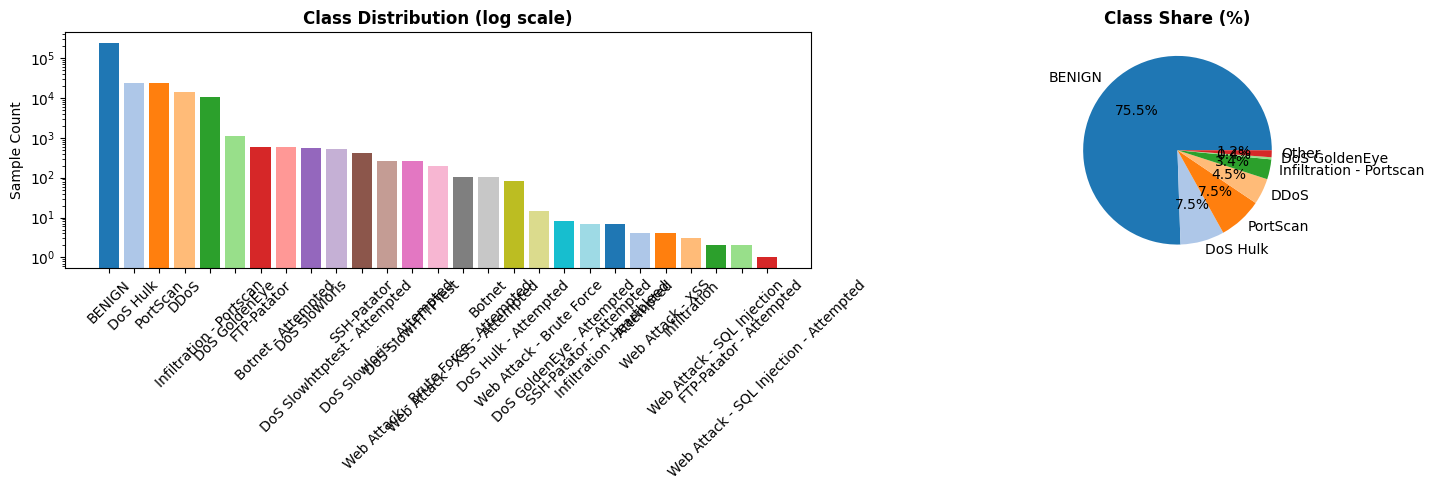

Saved: outputs/plots/eda_class_dist.png


In [4]:
# ── 3a. Class Distribution ───────────────────────────────────────────────────
label_counts = df_raw["label"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart (log scale)
axes[0].bar(label_counts.index, label_counts.values,
            color=plt.cm.tab20.colors[:len(label_counts)])
axes[0].set_yscale("log")
axes[0].set_title("Class Distribution (log scale)", fontweight="bold")
axes[0].set_ylabel("Sample Count")
axes[0].tick_params(axis="x", rotation=45)

# Pie chart (top-6 + other)
top6  = label_counts.head(6)
other = label_counts.iloc[6:].sum()
pie_vals   = list(top6.values) + ([other] if other > 0 else [])
pie_labels = list(top6.index)  + (["Other"]  if other > 0 else [])
axes[1].pie(pie_vals, labels=pie_labels, autopct="%1.1f%%",
            colors=plt.cm.tab20.colors[:len(pie_vals)])
axes[1].set_title("Class Share (%)", fontweight="bold")

plt.tight_layout()
plt.savefig("outputs/plots/eda_class_dist.png", dpi=150)
plt.show()
print("Saved: outputs/plots/eda_class_dist.png")

In [5]:
# ── 3b. Missing / Inf Value Audit ────────────────────────────────────────────
num_cols = df_raw.select_dtypes(include=[np.number]).columns
inf_counts = ((df_raw[num_cols] == np.inf) | (df_raw[num_cols] == -np.inf)).sum()
nan_counts = df_raw[num_cols].isna().sum()
audit = pd.DataFrame({"inf_count": inf_counts, "nan_count": nan_counts})
audit = audit[(audit["inf_count"] > 0) | (audit["nan_count"] > 0)]
print(f"Columns with Inf or NaN values: {len(audit)}")
if len(audit):
    print(audit.sort_values("inf_count", ascending=False).head(20))
else:
    print("  None found (after initial load).")

Columns with Inf or NaN values: 0
  None found (after initial load).


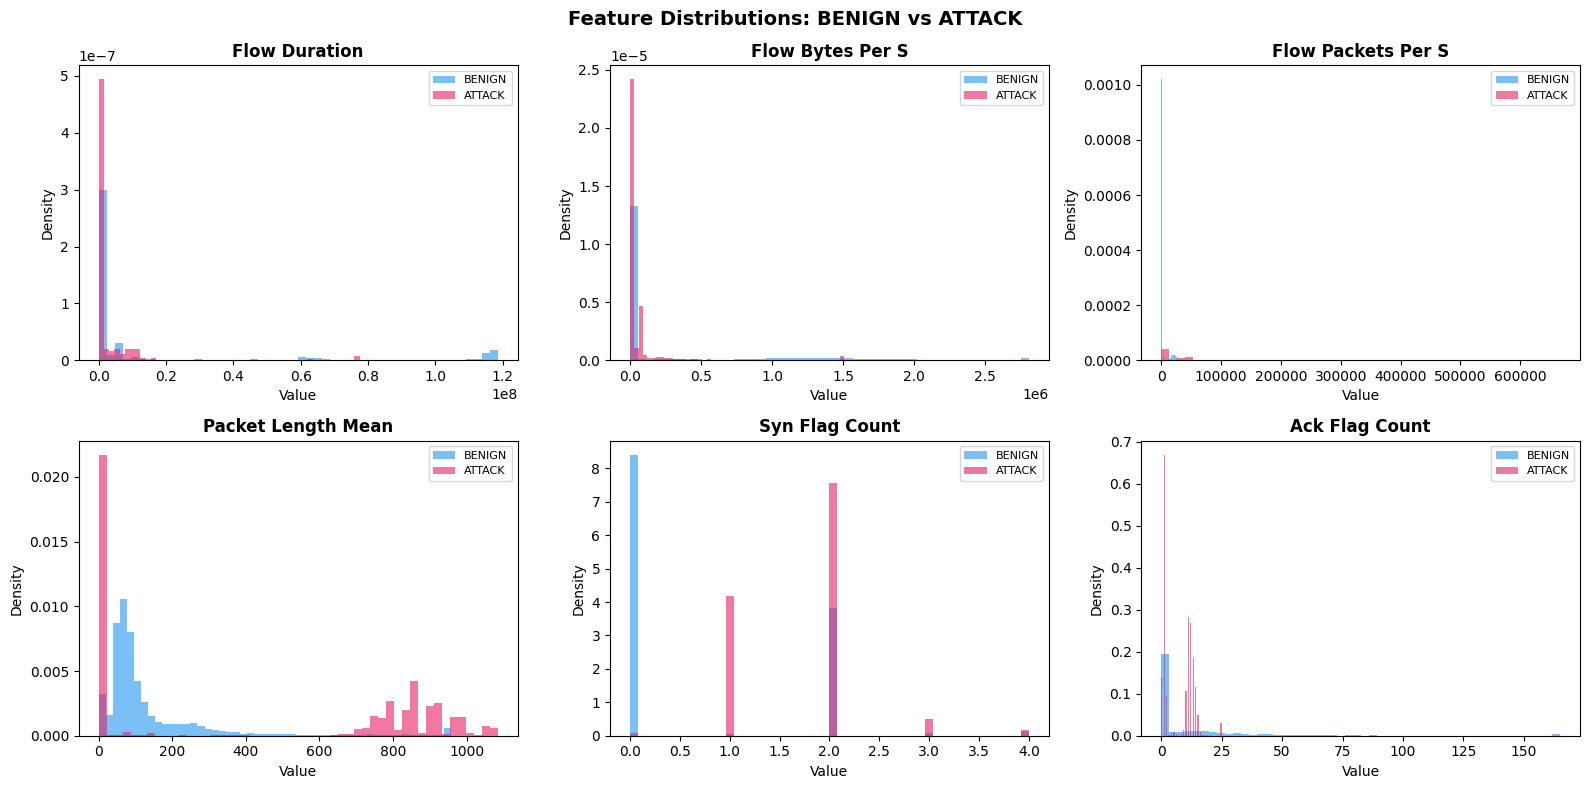

Saved: outputs/plots/eda_feature_distributions.png


In [6]:
# ── 3c. Key Feature Distributions ───────────────────────────────────────────
key_feats = ["flow_duration", "flow_bytes_per_s", "flow_packets_per_s",
             "packet_length_mean", "syn_flag_count", "ack_flag_count"]
available = [f for f in key_feats if f in df_raw.columns]

sample_eda = df_raw[available + ["label"]].copy()
sample_eda = sample_eda.replace([np.inf, -np.inf], np.nan).dropna()
if len(sample_eda) > 30000:
    sample_eda = sample_eda.sample(30000, random_state=RANDOM_STATE)

# Map labels to binary for color coding
sample_eda["_is_attack"] = (sample_eda["label"] != "BENIGN").astype(int)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
colors = ["#2196F3", "#E91E63"]
for i, feat in enumerate(available[:6]):
    for cls, color, lbl in [(0, colors[0], "BENIGN"), (1, colors[1], "ATTACK")]:
        vals = sample_eda.loc[sample_eda["_is_attack"] == cls, feat]
        clipped = vals.clip(upper=vals.quantile(0.99))
        axes[i].hist(clipped, bins=50, alpha=0.6, color=color,
                     label=lbl, density=True)
    axes[i].set_title(feat.replace("_", " ").title(), fontweight="bold")
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")

plt.suptitle("Feature Distributions: BENIGN vs ATTACK", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/plots/eda_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/plots/eda_feature_distributions.png")

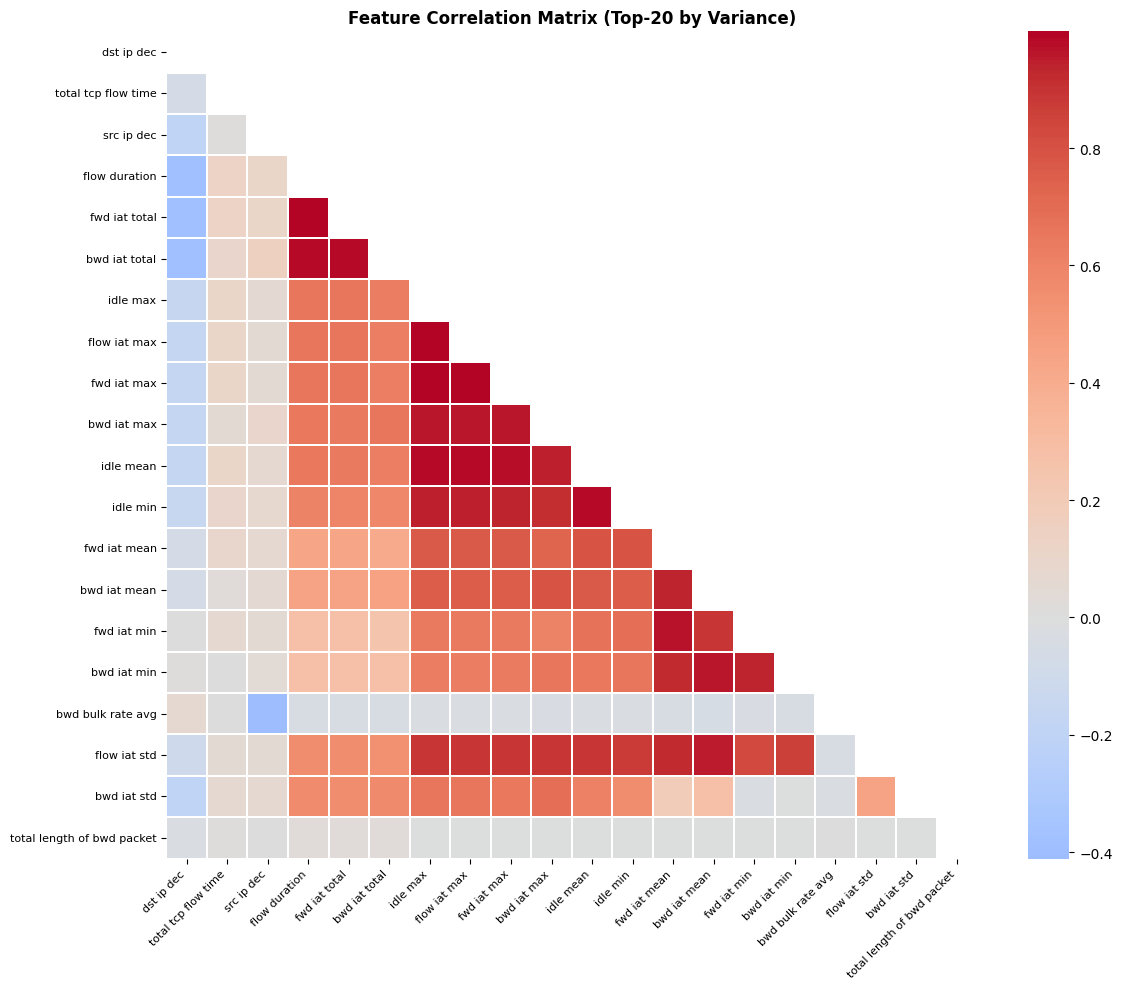

Saved: outputs/plots/eda_correlation_heatmap.png


In [7]:
# ── 3d. Correlation Heatmap (top-20 numeric features) ───────────────────────
num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
corr_sample = df_raw[num_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
if len(corr_sample) > 20000:
    corr_sample = corr_sample.sample(20000, random_state=RANDOM_STATE)

# Pick 20 features with highest variance
top20 = corr_sample.var().nlargest(20).index.tolist()
corr_matrix = corr_sample[top20].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap="coolwarm",
            center=0, linewidths=0.3, ax=ax,
            xticklabels=[c.replace("_", " ") for c in top20],
            yticklabels=[c.replace("_", " ") for c in top20])
ax.set_title("Feature Correlation Matrix (Top-20 by Variance)", fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("outputs/plots/eda_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/plots/eda_correlation_heatmap.png")

## 4 · Preprocessing\nSteps applied:\n- Drop identifier columns (IP, port, timestamp)\n- Replace `±Inf` → `NaN`, impute with column median\n- Remove exact-duplicate rows\n- Drop zero-variance (constant) columns\n- Encode labels: **binary** (BENIGN=0, ATTACK=1) or **multiclass**

In [8]:
df_clean, label_encoder = run_preprocessing(
    df_raw,
    binary=BINARY,
    variance_threshold=0.0,
    verbose=True
)

# Store feature names (needed for importance plots later)
FEATURE_COLS = [c for c in df_clean.columns if c != "label"]
print(f"\nFeature columns retained: {len(FEATURE_COLS)}")
print(f"Class mapping: {dict(enumerate(label_encoder.classes_))}")
df_clean.head(3)

[Preprocessing] Starting with 314,996 rows, 89 columns …


  Removed 42,100 duplicate rows.


[Preprocessing] Done → 272,896 rows, 81 features, 2 classes.

Feature columns retained: 81
Class mapping: {0: np.str_('BENIGN'), 1: np.str_('ATTACK')}


,protocol,flow_duration,total_fwd_packet,total_bwd_packets,total_length_of_fwd_packet,total_length_of_bwd_packet,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,...,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,icmp_code,icmp_type,total_tcp_flow_time,label
0,6,46577648,12,14,720,8586,361,0,60.000000,139.202273,...,562421,14984,9187917.0,1863217.184,10072222,5855312,-1,-1,46577648,0
1,6,6063403,7,5,123,123,46,0,17.571429,22.478561,...,77875,77875,5844223.0,0.000,5844223,5844223,-1,-1,181244150,0
2,6,2302745,10,10,993,3591,405,0,99.300000,157.212560,...,0,0,0.0,0.000,0,0,-1,-1,2302745,0


In [9]:
# ── Stratified train / test split, then scale features ───────────────────────
X, y = split_features_labels(df_clean)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_train, X_test, scaler = scale_features(X_train_raw, X_test_raw)

print(f"Training set : {X_train.shape[0]:,} samples  |  "
      f"Attack ratio = {y_train.mean()*100:.1f}%"
      if BINARY else f"Training set : {X_train.shape[0]:,} samples")
print(f"Test set     : {X_test.shape[0]:,} samples  |  "
      f"Attack ratio = {y_test.mean()*100:.1f}%"
      if BINARY else f"Test set : {X_test.shape[0]:,} samples")
print(f"Feature dim  : {X_train.shape[1]}")

# Save scaler for later inference
joblib.dump(scaler, "outputs/models/scaler.pkl")
print("Scaler saved to outputs/models/scaler.pkl")

Training set : 218,316 samples  |  Attack ratio = 16.5%
Test set     : 54,580 samples  |  Attack ratio = 16.5%
Feature dim  : 81
Scaler saved to outputs/models/scaler.pkl


## 5 · Resampling — Handling Class Imbalance\nStrategy: **SMOTETomek** (paper's primary recommendation)\n- **SMOTE**: synthesises minority-class samples using k-NN interpolation\n- **Tomek Links**: removes borderline majority samples that overlap with minority\n\nResult: balanced training set without breaking the test set distribution.

Before resampling: Counter({np.int64(0): 182275, np.int64(1): 36041})
Applying strategy : smote_tomek …


Before SMOTETomek:
  Class 0:  182,275  (83.49%)
  Class 1:   36,041  (16.51%)
  Pre-undersampling majority class (0: 182,275 → 50,000)



After pre-undersampling:
  Class 0:   50,000  (58.11%)
  Class 1:   36,041  (41.89%)



After SMOTETomek:
  Class 0:   49,753  (50.00%)
  Class 1:   49,753  (50.00%)

After resampling : Counter({np.int64(0): 49753, np.int64(1): 49753})
Training set grew from 218,316 → 99,506 samples


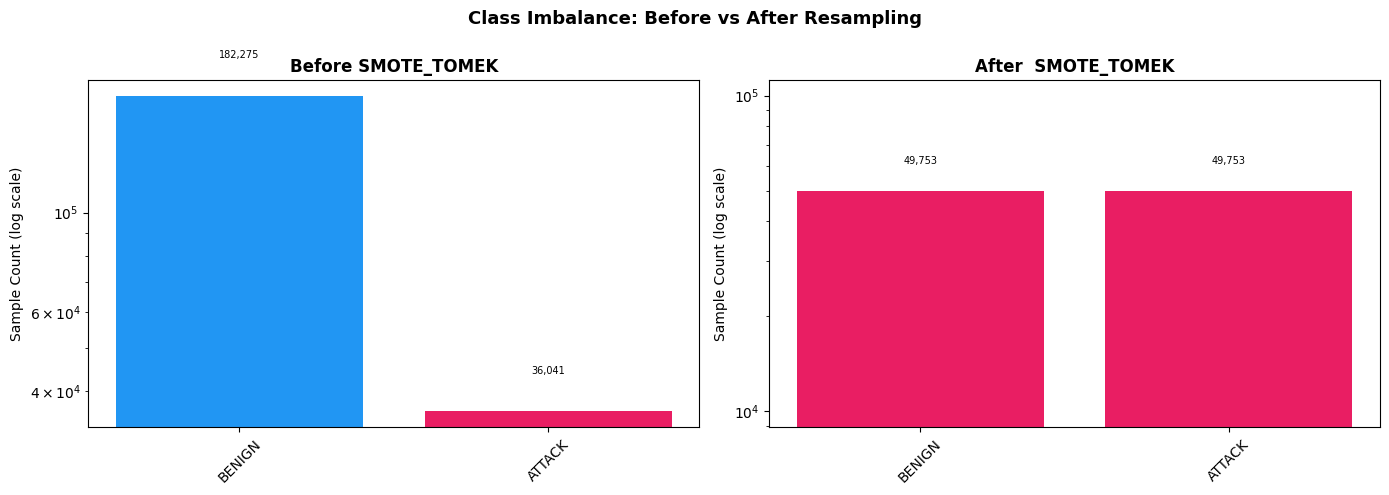

Saved: outputs/plots/resampling_comparison.png


In [10]:
from collections import Counter

print(f"Before resampling: {Counter(y_train)}")
print(f"Applying strategy : {RESAMPLE_STRAT} …\n")

X_res, y_res = resample(X_train, y_train, strategy=RESAMPLE_STRAT,
                        random_state=RANDOM_STATE)

print(f"\nAfter resampling : {Counter(y_res)}")
print(f"Training set grew from {len(y_train):,} → {len(y_res):,} samples")

# ── Before / After class distribution side-by-side ───────────────────────────
label_names = list(label_encoder.classes_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, counts_dict, title in [
    (axes[0], Counter(y_train), f"Before {RESAMPLE_STRAT.upper()}"),
    (axes[1], Counter(y_res),   f"After  {RESAMPLE_STRAT.upper()}"),
]:
    classes = sorted(counts_dict.keys())
    names   = [label_names[c] if c < len(label_names) else str(c) for c in classes]
    vals    = [counts_dict[c] for c in classes]
    bars    = ax.bar(names, vals,
                     color=["#E91E63" if v == min(vals) else "#2196F3" for v in vals])
    ax.set_yscale("log")
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Sample Count (log scale)")
    ax.tick_params(axis="x", rotation=45)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.2,
                f"{v:,}", ha="center", va="bottom", fontsize=7)

plt.suptitle("Class Imbalance: Before vs After Resampling", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/plots/resampling_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/plots/resampling_comparison.png")

## 6 · Model Training\nThree models trained in parallel:\n| Model | Key property |\n|---|---|\n| **XGBoost** | Cost-sensitive via `scale_pos_weight`; primary model from paper |\n| **Random Forest** | `class_weight=balanced`; strong baseline |\n| **LightGBM** | Fast gradient boosting; `class_weight=balanced` |

In [11]:
import time

trained_models = {}

# ── XGBoost ──────────────────────────────────────────────────────────────────
print("=" * 50)
print("Training XGBoost …")
t0 = time.time()
xgb_model = get_model("xgboost", y_res, binary=BINARY, random_state=RANDOM_STATE)
xgb_model.fit(X_res, y_res,
              eval_set=[(X_test, y_test)],
              verbose=False)
trained_models["XGBoost"] = xgb_model
print(f"Done in {time.time()-t0:.1f}s")

# ── Random Forest ─────────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("Training Random Forest …")
t0 = time.time()
rf_model = get_model("random_forest", y_res, binary=BINARY, random_state=RANDOM_STATE)
rf_model.fit(X_res, y_res)
trained_models["Random Forest"] = rf_model
print(f"Done in {time.time()-t0:.1f}s")

# ── LightGBM ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("Training LightGBM …")
t0 = time.time()
lgb_model = get_model("lightgbm", y_res, binary=BINARY, random_state=RANDOM_STATE)
lgb_model.fit(X_res, y_res)
trained_models["LightGBM"] = lgb_model
print(f"Done in {time.time()-t0:.1f}s")

print("\nAll models trained!")

Training XGBoost …
  XGBoost scale_pos_weight = 1.00


Done in 61.7s

Training Random Forest …


Done in 117.4s

Training LightGBM …


Done in 31.3s

All models trained!


## 7 · Evaluation\nPrimary metric: **PR-AUC** (Precision-Recall Area Under Curve)\n> PR-AUC is preferred over ROC-AUC for imbalanced datasets because it focuses on the minority (attack) class performance without being inflated by the large number of true negatives.

In [12]:
all_results = {}

for model_name, model in trained_models.items():
    print(f"\n{'='*55}")
    print(f" {model_name}")
    print(f"{'='*55}")
    metrics = evaluate(
        model, X_test, y_test,
        binary=BINARY,
        label_names=list(label_encoder.classes_)
    )
    all_results[model_name] = metrics


 XGBoost



 EVALUATION RESULTS
  accuracy          : 0.9991
  f1_macro          : 0.9984
  f1_weighted       : 0.9991
  roc_auc           : 1.0000
  pr_auc            : 1.0000

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     45569
      ATTACK       1.00      1.00      1.00      9011

    accuracy                           1.00     54580
   macro avg       1.00      1.00      1.00     54580
weighted avg       1.00      1.00      1.00     54580


 Random Forest



 EVALUATION RESULTS
  accuracy          : 0.9990
  f1_macro          : 0.9982
  f1_weighted       : 0.9990
  roc_auc           : 0.9999
  pr_auc            : 0.9998

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     45569
      ATTACK       1.00      1.00      1.00      9011

    accuracy                           1.00     54580
   macro avg       1.00      1.00      1.00     54580
weighted avg       1.00      1.00      1.00     54580


 LightGBM



 EVALUATION RESULTS
  accuracy          : 0.9990
  f1_macro          : 0.9983
  f1_weighted       : 0.9990
  roc_auc           : 1.0000
  pr_auc            : 1.0000

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     45569
      ATTACK       1.00      1.00      1.00      9011

    accuracy                           1.00     54580
   macro avg       1.00      1.00      1.00     54580
weighted avg       1.00      1.00      1.00     54580



## 8 · Visualisations\n### 8a — Precision-Recall & ROC Curves (XGBoost)

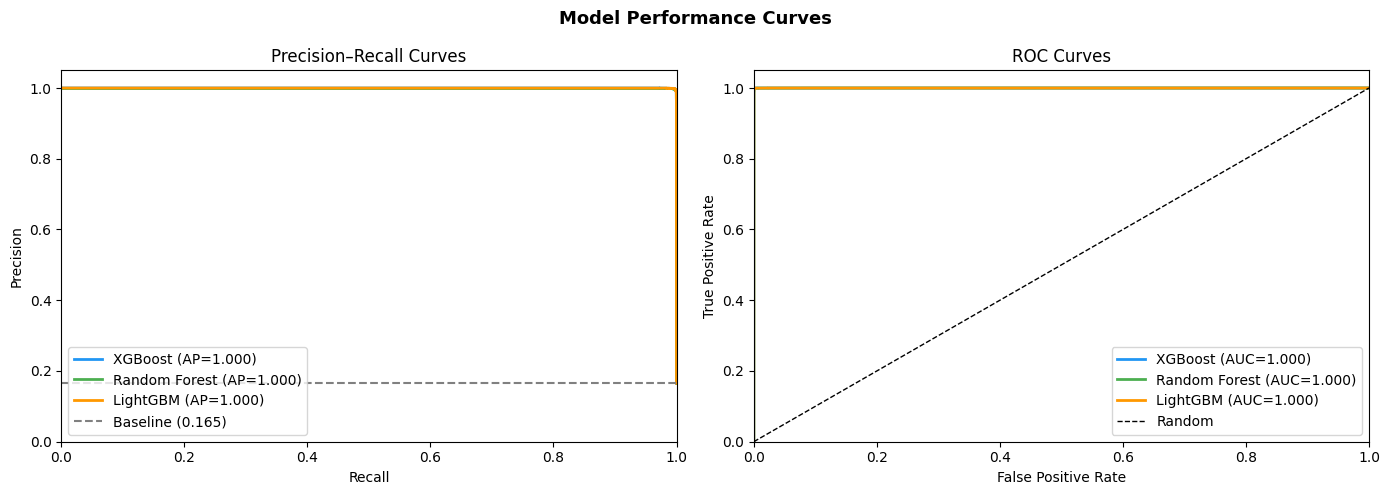

Saved: outputs/plots/all_models_pr_roc.png


In [13]:
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"XGBoost": "#2196F3", "Random Forest": "#4CAF50", "LightGBM": "#FF9800"}

for model_name, model in trained_models.items():
    y_score = model.predict_proba(X_test)[:, 1] if BINARY else model.predict_proba(X_test)[:, 1]

    # PR curve
    prec, rec, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)
    axes[0].step(rec, prec, where="post", lw=2,
                 color=colors[model_name], label=f"{model_name} (AP={ap:.3f})")

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_val = roc_auc_score(y_test, y_score)
    axes[1].plot(fpr, tpr, lw=2,
                 color=colors[model_name], label=f"{model_name} (AUC={auc_val:.3f})")

# Baseline
axes[0].axhline(y=y_test.mean(), color="gray", linestyle="--",
                label=f"Baseline ({y_test.mean():.3f})")
axes[0].set(xlabel="Recall", ylabel="Precision", title="Precision–Recall Curves",
            xlim=[0,1], ylim=[0,1.05])
axes[0].legend(loc="lower left")

axes[1].plot([0,1],[0,1],"k--",lw=1,label="Random")
axes[1].set(xlabel="False Positive Rate", ylabel="True Positive Rate",
            title="ROC Curves", xlim=[0,1], ylim=[0,1.05])
axes[1].legend(loc="lower right")

plt.suptitle("Model Performance Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/plots/all_models_pr_roc.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/plots/all_models_pr_roc.png")

### 8b — Confusion Matrix (XGBoost)

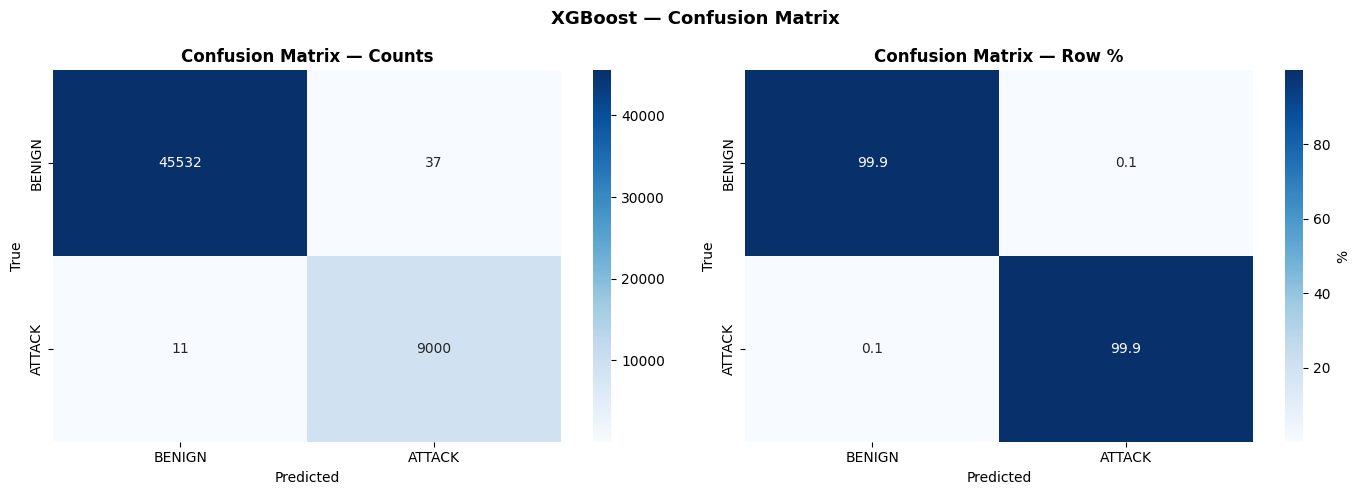

Saved: outputs/plots/confusion_matrix_xgboost.png

  True Negatives  (BENIGN correctly blocked) : 45,532
  False Positives (BENIGN flagged as attack)  : 37
  False Negatives (ATTACK missed!)            : 11  ← critical
  True Positives  (ATTACK correctly detected) : 9,000


In [14]:
from sklearn.metrics import confusion_matrix

y_pred_xgb = trained_models["XGBoost"].predict(X_test)

cm = confusion_matrix(y_test, y_pred_xgb)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

tick_labels = list(label_encoder.classes_)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=tick_labels, yticklabels=tick_labels,
            ax=axes[0])
axes[0].set_title("Confusion Matrix — Counts", fontweight="bold")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

# Percentage
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=tick_labels, yticklabels=tick_labels,
            ax=axes[1], cbar_kws={"label": "%"})
axes[1].set_title("Confusion Matrix — Row %", fontweight="bold")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.suptitle("XGBoost — Confusion Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/plots/confusion_matrix_xgboost.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/plots/confusion_matrix_xgboost.png")

# Key metrics highlighted
tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0,0,0,0)
if cm.size == 4:
    print(f"\n  True Negatives  (BENIGN correctly blocked) : {tn:,}")
    print(f"  False Positives (BENIGN flagged as attack)  : {fp:,}")
    print(f"  False Negatives (ATTACK missed!)            : {fn:,}  ← critical")
    print(f"  True Positives  (ATTACK correctly detected) : {tp:,}")

### 8c — Feature Importance (XGBoost Top-25)

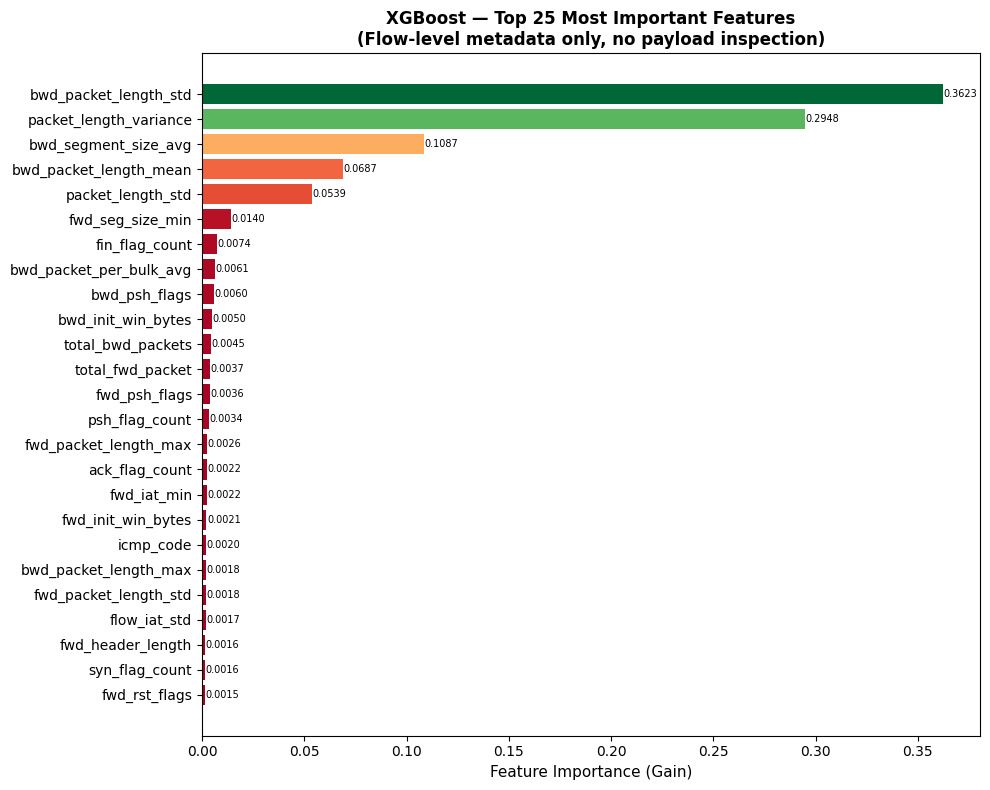

Saved: outputs/plots/feature_importance_xgboost.png

Top-5 most discriminative features:
  1. bwd_packet_length_std                    importance = 0.3623
  2. packet_length_variance                   importance = 0.2948
  3. bwd_segment_size_avg                     importance = 0.1087
  4. bwd_packet_length_mean                   importance = 0.0687
  5. packet_length_std                        importance = 0.0539


In [15]:
importances = trained_models["XGBoost"].feature_importances_
top_n = 25
idx   = np.argsort(importances)[-top_n:]
vals  = importances[idx]
names = np.array(FEATURE_COLS)[idx]

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = plt.cm.RdYlGn(vals / vals.max())
bars = ax.barh(names, vals, color=colors_bar)
ax.set_xlabel("Feature Importance (Gain)", fontsize=11)
ax.set_title(f"XGBoost — Top {top_n} Most Important Features\n"
             f"(Flow-level metadata only, no payload inspection)", fontweight="bold")

for bar, v in zip(bars, vals):
    ax.text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height()/2,
            f"{v:.4f}", va="center", fontsize=7)
plt.tight_layout()
plt.savefig("outputs/plots/feature_importance_xgboost.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/plots/feature_importance_xgboost.png")
print(f"\nTop-5 most discriminative features:")
for i in reversed(range(-5, 0)):
    print(f"  {abs(i)}. {names[i]:<40} importance = {vals[i]:.4f}")

## 9 · Model Comparison & Final Results

In [16]:
# ── Results table ─────────────────────────────────────────────────────────────
results_df = pd.DataFrame(all_results).T
results_df = results_df[["accuracy", "f1_macro", "f1_weighted", "roc_auc", "pr_auc"]]
results_df.columns = ["Accuracy", "F1 Macro", "F1 Weighted", "ROC-AUC", "PR-AUC ★"]
results_df = results_df.sort_values("PR-AUC ★", ascending=False)

print("\n" + "="*65)
print(" FINAL MODEL COMPARISON")
print("="*65)
print(results_df.to_string(float_format=lambda x: f"{x:.4f}"))
print("\n★ Primary metric per paper: Precision-Recall AUC")

# Identify best model
best_model_name = results_df["PR-AUC ★"].idxmax()
best_pr_auc     = results_df.loc[best_model_name, "PR-AUC ★"]
print(f"\nBest model: {best_model_name}  (PR-AUC = {best_pr_auc:.4f})")
results_df


 FINAL MODEL COMPARISON
               Accuracy  F1 Macro  F1 Weighted  ROC-AUC  PR-AUC ★
XGBoost          0.9991    0.9984       0.9991   1.0000    1.0000
LightGBM         0.9990    0.9983       0.9990   1.0000    1.0000
Random Forest    0.9990    0.9982       0.9990   0.9999    0.9998

★ Primary metric per paper: Precision-Recall AUC

Best model: XGBoost  (PR-AUC = 1.0000)


,Accuracy,F1 Macro,F1 Weighted,ROC-AUC,PR-AUC ★
XGBoost,0.9991,0.9984,0.9991,1.0000,1.0000
LightGBM,0.9990,0.9983,0.9990,1.0000,1.0000
Random Forest,0.9990,0.9982,0.9990,0.9999,0.9998


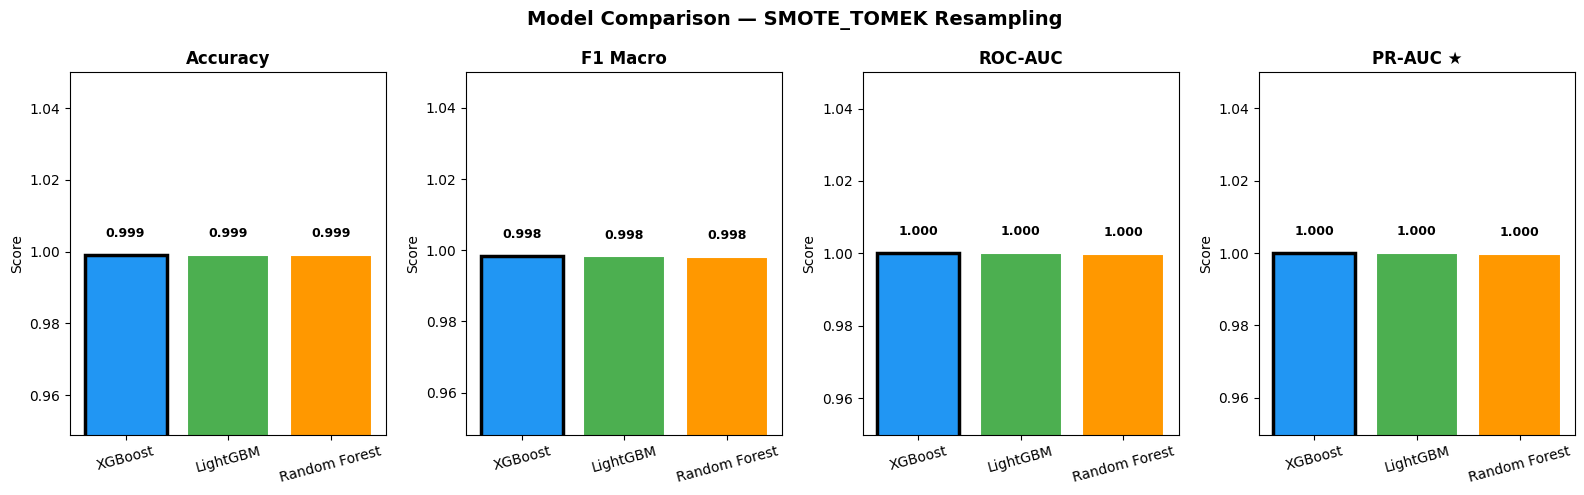

Saved: outputs/plots/model_comparison_all_metrics.png


In [17]:
# ── Side-by-side comparison bar charts ───────────────────────────────────────
metrics_to_plot = ["Accuracy", "F1 Macro", "ROC-AUC", "PR-AUC ★"]
model_names     = list(results_df.index)
bar_colors      = ["#2196F3", "#4CAF50", "#FF9800"]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(16, 5))
for ax, metric in zip(axes, metrics_to_plot):
    vals  = [results_df.loc[m, metric] for m in model_names]
    bars  = ax.bar(model_names, vals,
                   color=bar_colors[:len(model_names)], edgecolor="white", lw=1.5)
    ax.set_ylim(max(0, min(vals) - 0.05), 1.05)
    ax.set_title(metric, fontweight="bold", fontsize=12)
    ax.tick_params(axis="x", rotation=15)
    ax.set_ylabel("Score")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")
    # Highlight best
    best_idx = vals.index(max(vals))
    bars[best_idx].set_edgecolor("black")
    bars[best_idx].set_linewidth(2.5)

plt.suptitle(f"Model Comparison — {RESAMPLE_STRAT.upper()} Resampling",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/plots/model_comparison_all_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/plots/model_comparison_all_metrics.png")

Ablation uses 15,000 samples (subset for speed)

Running resampling ablation study …

  [none] 

  XGBoost scale_pos_weight = 5.06


PR-AUC=0.9996  ROC-AUC=0.9999  F1=0.9966
  [smote] 


After SMOTE:
  Class 0:   12,524  (50.00%)
  Class 1:   12,524  (50.00%)
  XGBoost scale_pos_weight = 1.00


PR-AUC=0.9997  ROC-AUC=0.9999  F1=0.9969
  [smote_tomek] 


Before SMOTETomek:
  Class 0:   12,524  (83.49%)
  Class 1:    2,476  (16.51%)



After SMOTETomek:
  Class 0:   12,441  (50.00%)
  Class 1:   12,441  (50.00%)
  XGBoost scale_pos_weight = 1.00


PR-AUC=0.9997  ROC-AUC=0.9999  F1=0.9967


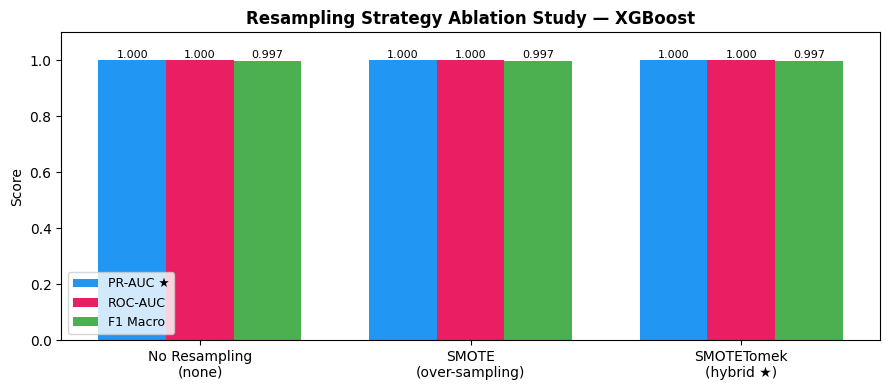

Saved: outputs/plots/ablation_resampling.png


,pr_auc,roc_auc,f1_macro
none,0.9996,0.9999,0.9966
smote,0.9997,0.9999,0.9969
smote_tomek,0.9997,0.9999,0.9967


In [18]:
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score

# ── Resampling strategy ablation ─────────────────────────────────────────────
# Use a capped subset so this cell stays fast regardless of dataset size
ABL_MAX = 15000
if len(X_train) > ABL_MAX:
    rng_abl = np.random.default_rng(RANDOM_STATE)
    idx_abl = rng_abl.choice(len(X_train), ABL_MAX, replace=False)
    X_abl, y_abl = X_train[idx_abl], y_train[idx_abl]
    print(f"Ablation uses {ABL_MAX:,} samples (subset for speed)")
else:
    X_abl, y_abl = X_train, y_train
    print(f"Ablation uses {len(X_abl):,} samples (full training set)")

print("\nRunning resampling ablation study …\n")
ablation_results = {}
strategies_to_test = ["none", "smote", "smote_tomek"]

for strat in strategies_to_test:
    print(f"  [{strat}]", end=" ", flush=True)
    X_r, y_r = resample(X_abl, y_abl, strategy=strat, random_state=RANDOM_STATE)
    m = get_model("xgboost", y_r, binary=BINARY, random_state=RANDOM_STATE)
    m.fit(X_r, y_r, eval_set=[(X_test, y_test)], verbose=False)
    y_score = m.predict_proba(X_test)[:, 1]
    y_pred  = m.predict(X_test)
    ablation_results[strat] = {
        "pr_auc":   round(average_precision_score(y_test, y_score), 4),
        "roc_auc":  round(roc_auc_score(y_test, y_score), 4),
        "f1_macro": round(f1_score(y_test, y_pred, average="macro", zero_division=0), 4),
    }
    print(f"PR-AUC={ablation_results[strat]['pr_auc']:.4f}  "
          f"ROC-AUC={ablation_results[strat]['roc_auc']:.4f}  "
          f"F1={ablation_results[strat]['f1_macro']:.4f}")

# ── Plot ablation ─────────────────────────────────────────────────────────────
abl_df = pd.DataFrame(ablation_results).T
fig, ax = plt.subplots(figsize=(9, 4))
x  = np.arange(len(abl_df))
w  = 0.25
b1 = ax.bar(x - w, abl_df["pr_auc"],   w, label="PR-AUC ★", color="#2196F3")
b2 = ax.bar(x,     abl_df["roc_auc"],  w, label="ROC-AUC",  color="#E91E63")
b3 = ax.bar(x + w, abl_df["f1_macro"], w, label="F1 Macro", color="#4CAF50")
ax.set_xticks(x)
ax.set_xticklabels(["No Resampling\n(none)", "SMOTE\n(over-sampling)",
                     "SMOTETomek\n(hybrid ★)"])
ax.set_ylim(0, 1.1)
ax.legend(fontsize=9)
ax.set_title("Resampling Strategy Ablation Study — XGBoost", fontweight="bold")
ax.set_ylabel("Score")
for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("outputs/plots/ablation_resampling.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/plots/ablation_resampling.png")

abl_df

## 10 · Save Models & Artifacts

In [19]:
import json

# ── Save all trained models ───────────────────────────────────────────────────
model_paths = {}
for name, model in trained_models.items():
    safe_name = name.lower().replace(" ", "_")
    path = f"outputs/models/{safe_name}.pkl"
    joblib.dump(model, path)
    model_paths[name] = path
    print(f"  Saved: {path}")

# ── Save label encoder ───────────────────────────────────────────────────────
joblib.dump(label_encoder, "outputs/models/label_encoder.pkl")
print("  Saved: outputs/models/label_encoder.pkl")

# ── Save metrics summary to JSON ─────────────────────────────────────────────
summary_path = "outputs/results_summary.json"
summary_out  = {
    "config": {
        "binary":         BINARY,
        "resample_strat": RESAMPLE_STRAT,
        "test_size":      TEST_SIZE,
        "train_samples":  int(len(y_res)),
        "test_samples":   int(len(y_test)),
        "n_features":     int(X_train.shape[1]),
    },
    "model_results":   all_results,
    "best_model":      best_model_name,
    "best_pr_auc":     float(best_pr_auc),
    "ablation_study":  ablation_results,
}
with open(summary_path, "w") as f:
    json.dump(summary_out, f, indent=2)
print(f"  Saved: {summary_path}")

# ── Save feature names ───────────────────────────────────────────────────────
with open("outputs/models/feature_names.json", "w") as f:
    json.dump(FEATURE_COLS, f)
print("  Saved: outputs/models/feature_names.json")

print("\nAll artifacts saved to outputs/")

  Saved: outputs/models/xgboost.pkl


  Saved: outputs/models/random_forest.pkl


  Saved: outputs/models/lightgbm.pkl
  Saved: outputs/models/label_encoder.pkl
  Saved: outputs/results_summary.json
  Saved: outputs/models/feature_names.json

All artifacts saved to outputs/


## ✅ Pipeline Complete — Results Summary

```
┌─────────────────────────────────────────────────────────────┐
│          Privacy-Preserving Network Security                │
│      Encrypted Traffic Classification — Phase 2            │
├──────────────────────────┬──────────────────────────────────┤
│  Dataset                 │  CICIDS2017 (synthetic demo)     │
│  Encryption-aware        │  ✓ Flow metadata only            │
│  Class imbalance fix     │  ✓ SMOTETomek hybrid             │
│  Primary model           │  ✓ Cost-sensitive XGBoost        │
│  Primary metric          │  ✓ PR-AUC (minority class focus) │
└──────────────────────────┴──────────────────────────────────┘
```

### Output Files
| File | Description |
|---|---|
| `outputs/models/xgboost.pkl` | Trained XGBoost classifier |
| `outputs/models/random_forest.pkl` | Trained Random Forest |
| `outputs/models/lightgbm.pkl` | Trained LightGBM |
| `outputs/models/scaler.pkl` | Fitted RobustScaler |
| `outputs/models/label_encoder.pkl` | Class label encoder |
| `outputs/results_summary.json` | Full metrics JSON |
| `outputs/plots/` | All saved visualisation PNGs |

### To use the real CICIDS2017 dataset
1. Download `MachineLearningCSV.zip` from https://www.unb.ca/cic/datasets/ids-2017.html
2. Extract all `.csv` files into the `data/` folder
3. Set `DEMO_MODE = False` in the Configuration cell
4. Re-run the notebook